# Progetto finale parte 2

## Librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from scipy import stats
from scipy.stats import randint, loguniform


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             balanced_accuracy_score, roc_auc_score, matthews_corrcoef, make_scorer)
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.model_selection import cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

## Il Dataset
In questo paragrafo:
- un primo sguardo ai dati
- statistiche descrittive
- ricerca e gestione di eventuali valori mancanti
- controllo di coerenza sul dataset test.csv

In [2]:
pd.set_option('display.max_columns', None)  # per vedere tutte le colonne senza troncamenti

# 2. Caricamento dei due dataset così come sono stati forniti
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

train.head()

Train shape: (103904, 25)
Test shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
# 3. Struttura del dataset: tipi di dato e info generali
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [4]:
# 4. Le colonne "Unnamed: 0" e "id" sono solo identificativi (indice progressivo e ID passeggero):
#    non portano informazione predittiva, quindi vengono eliminate subito. Stessa cosa su test per coerenza.
train = train.drop(columns=['Unnamed: 0', 'id'])
test = test.drop(columns=['Unnamed: 0', 'id'])

print(train.shape, test.shape)

(103904, 23) (25976, 23)


In [5]:
# 5. Statistiche descrittive delle variabili numeriche
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358158,1.332991,0.0,2.0,4.0,4.0,5.0


Le 14 colonne di rating (wifi, cibo, boarding, comfort ecc.) sono in realtà scale ordinali da 0 a 5, tecnicamente numeriche discrete, ma concettualmente categoriche ordinate. In seguito potrebbe avere senso trattarle diversamente da variabili continue come Age, Flight Distance o i ritardi in minuti.

In [6]:
# 6. Separazione delle colonne in categoriche e numeriche, così da avere chiaro
#    su cosa ragionare nei prossimi step (encoding, scaling, correlazioni...)
target = 'satisfaction'

categorical_cols = train.select_dtypes(include='object').columns.tolist()
categorical_cols.remove(target)  # il target viene trattato a parte

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categoriche:", categorical_cols)
print("Numeriche:", numerical_cols)

Categoriche: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeriche: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [7]:
# 7. Verifica esplicita dei valori mancanti
missing_train = train.isna().sum()
missing_train = missing_train[missing_train > 0]

print("Valori mancanti nel TRAIN:")
print(missing_train)
print(f"\nPercentuale sul totale righe: {(missing_train / len(train) * 100).round(3)}")

Valori mancanti nel TRAIN:
Arrival Delay in Minutes    310
dtype: int64

Percentuale sul totale righe: Arrival Delay in Minutes    0.298
dtype: float64


In [8]:
# 8. Controllo anche del test, solo per sapere se sarà da gestire
#    (senza usarlo per decidere la strategia di imputazione)
missing_test = test.isna().sum()
missing_test = missing_test[missing_test > 0]
print("Valori mancanti nel TEST:")
print(missing_test)

Valori mancanti nel TEST:
Arrival Delay in Minutes    83
dtype: int64


Skewness Arrival Delay: 6.596636807462696

Correlazione con Departure Delay:
                            Departure Delay in Minutes  \
Departure Delay in Minutes                    1.000000   
Arrival Delay in Minutes                      0.965481   

                            Arrival Delay in Minutes  
Departure Delay in Minutes                  0.965481  
Arrival Delay in Minutes                    1.000000  


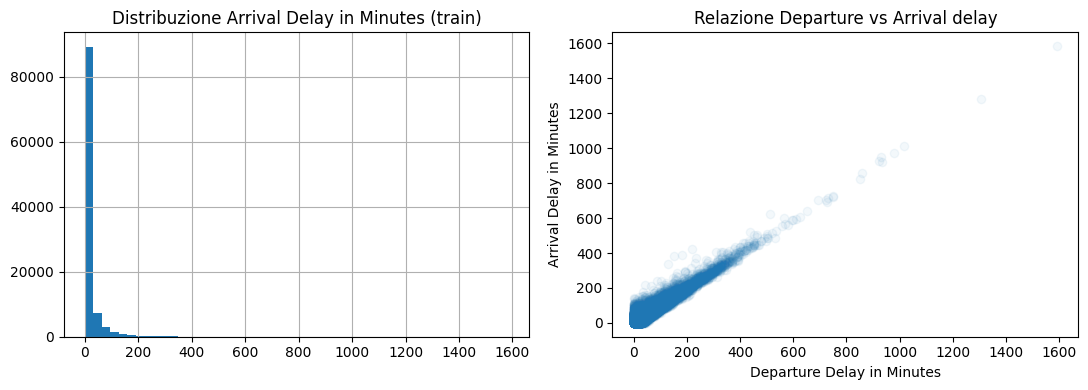

In [9]:
# 9. Analisi della variabile prima di decidere come trattare i NaN
print("Skewness Arrival Delay:", train['Arrival Delay in Minutes'].skew())
print("\nCorrelazione con Departure Delay:")
print(train[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].corr())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

train['Arrival Delay in Minutes'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribuzione Arrival Delay in Minutes (train)')

axes[1].scatter(train['Departure Delay in Minutes'], train['Arrival Delay in Minutes'], alpha=0.05)
axes[1].set_xlabel('Departure Delay in Minutes')
axes[1].set_ylabel('Arrival Delay in Minutes')
axes[1].set_title('Relazione Departure vs Arrival delay')

plt.tight_layout()
plt.show()

Si nota una correlazione fortissima tra "Departure Delay in Minutes" e "Arrival Delay in Minutes" (0.965). Dato che i due ritardi sono quasi sempre molto simili tra loro, invece di usare la mediana, ogni Arrival Delay mancante sarà imputato con il Departure Delay della stessa riga.

In [10]:
# 10. Imputazione mirata: dato il forte legame (corr = 0.965) tra i due ritardi,
#     usando il Departure Delay della stessa riga come miglior stima per l'Arrival Delay mancante.

train['Arrival Delay in Minutes'] = train['Arrival Delay in Minutes'].fillna(train['Departure Delay in Minutes'])
test['Arrival Delay in Minutes'] = test['Arrival Delay in Minutes'].fillna(test['Departure Delay in Minutes'])

# Verifica che non ci siano più NaN
print("NaN residui in train:", train['Arrival Delay in Minutes'].isna().sum())
print("NaN residui in test:", test['Arrival Delay in Minutes'].isna().sum())

NaN residui in train: 0
NaN residui in test: 0


---

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

satisfaction
neutral or dissatisfied    56.67
satisfied                  43.33
Name: proportion, dtype: float64


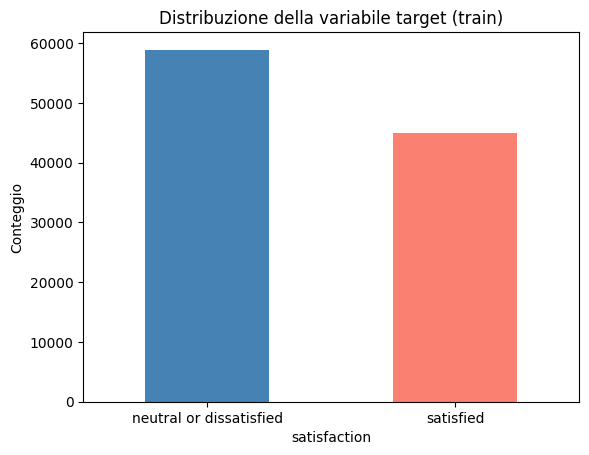

In [11]:
# 11. Distribuzione della variabile target sul train
target_counts = train['satisfaction'].value_counts()
target_perc = train['satisfaction'].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_perc.round(2))

target_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribuzione della variabile target (train)')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.show()

In [12]:
# 12. Controllo, solo per coerenza, che la stessa proporzione si mantenga nel test
#     (non verrà usato per decidere nulla, serve solo a verificare che train e test
#      siano stati campionati in modo simile)
print(test['satisfaction'].value_counts(normalize=True).round(4) * 100)

satisfaction
neutral or dissatisfied    56.1
satisfied                  43.9
Name: proportion, dtype: float64


## Analisi delle variabili categoriche

In [13]:
# 13. Esplorazione di ogni variabile categorica: modalità presenti e frequenze
for col in categorical_cols:
    print(f"--- {col} ---")
    print(train[col].value_counts())
    print((train[col].value_counts(normalize=True) * 100).round(2))
    print()

--- Gender ---
Gender
Female    52727
Male      51177
Name: count, dtype: int64
Gender
Female    50.75
Male      49.25
Name: proportion, dtype: float64

--- Customer Type ---
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64
Customer Type
Loyal Customer       81.73
disloyal Customer    18.27
Name: proportion, dtype: float64

--- Type of Travel ---
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64
Type of Travel
Business travel    68.96
Personal Travel    31.04
Name: proportion, dtype: float64

--- Class ---


Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64
Class
Business    47.80
Eco         44.99
Eco Plus     7.21
Name: proportion, dtype: float64



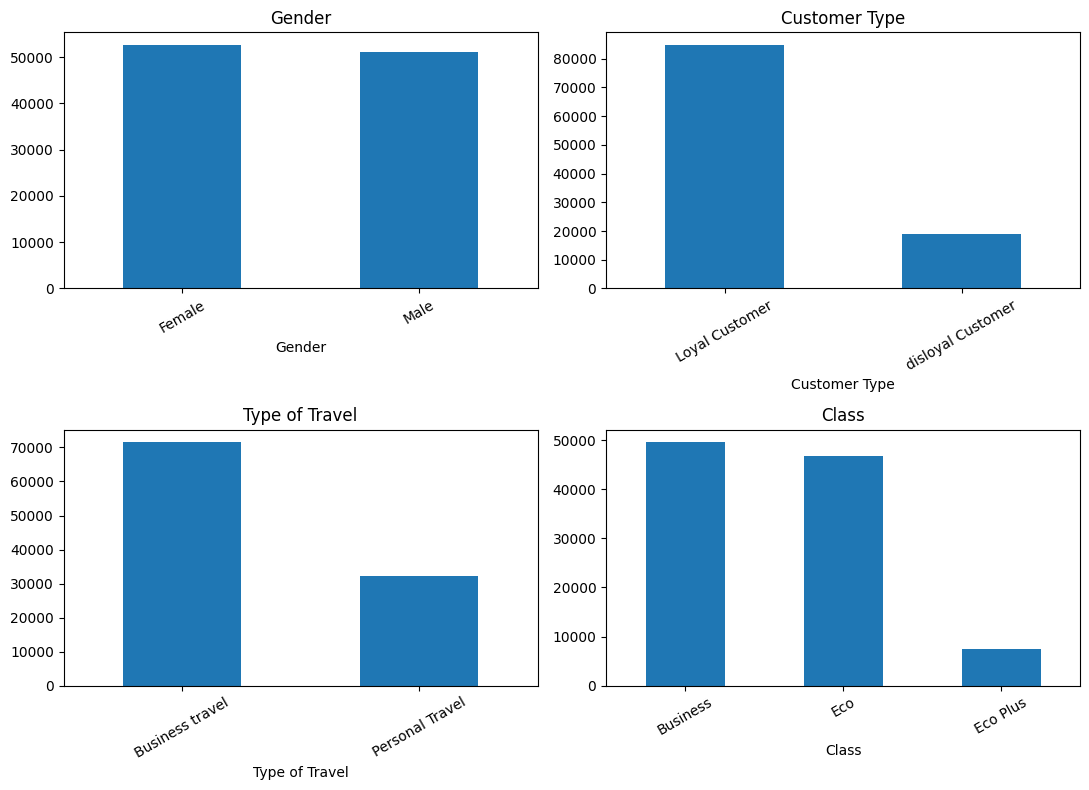

In [14]:
# 14. Visualizzazione
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    train[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Le quattro variabili categoriche presentano gradi di bilanciamento molto diversi tra loro.

`Gender` è sostanzialmente equidistribuita tra le due modalità (50.75% Female, 49.25% Male): da sola non sembra una variabile particolarmente distintiva, anche se la sua eventuale rilevanza andrà verificata più avanti con i test statistici.

`Customer Type` è invece fortemente sbilanciata: l'81.73% dei passeggeri nel dataset sono "Loyal Customer" contro solo il 18.27% di "disloyal Customer". Non si tratta di uno sbilanciamento del target e quindi non richiede tecniche di ribilanciamento, ma va tenuto presente: le stime relative alla categoria minoritaria (clienti non fedeli) saranno naturalmente meno robuste, avendo meno osservazioni a supporto.

Anche `Type of Travel` mostra una prevalenza netta: il 68.96% dei viaggi sono di lavoro (Business travel) contro il 31.04% di viaggi personali, coerente con il fatto che si tratta comunque di dati di una compagnia aerea.

`Class` conferma un pattern simile: le classi Business (47.80%) ed Eco (44.99%) si dividono quasi tutti i passeggeri, mentre Eco Plus è marginale (solo 7.21%). Trattandosi di una variabile con un ordine naturale legato al livello di servizio, è stata codificata come ordinale (Eco < Eco Plus < Business) invece che con un One-Hot Encoding, proprio per preservare questa gerarchia.

In generale nessuna di queste distribuzioni è un problema per l'EDA in sé, perché descrivono la composizione del dataset e non il target, ma la scarsa rappresentazione di alcune categorie (Eco Plus su tutte) è un elemento da ricordare più avanti, al momento di valutare la significatività statistica delle feature con Chi-square, Mutual Information e T-test.

In [15]:
# 15. Le tre variabili binarie: codifica diretta 0/1 (equivalente a One-Hot con drop_first)
binary_maps = {
    'Gender': {'Female': 0, 'Male': 1},
    'Customer Type': {'disloyal Customer': 0, 'Loyal Customer': 1},
    'Type of Travel': {'Personal Travel': 0, 'Business travel': 1},
}

for col, mapping in binary_maps.items():
    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)

# 16. 'Class' ha un ordine naturale (Eco < Eco Plus < Business) -> Ordinal Encoding
class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
train['Class'] = train['Class'].map(class_map)
test['Class'] = test['Class'].map(class_map)

train[categorical_cols].head()

,Gender,Customer Type,Type of Travel,Class
0,1,1,0,1
1,1,0,1,2
2,0,1,1,2
3,0,1,1,2
4,1,1,1,2


In [16]:
# 17. Codifica in 0/1 anche il target: servirà in seguito
#     per la correlation matrix e per i test statistici (Chi-square, T-test...), che richiedono valori numerici.
target_map = {'neutral or dissatisfied': 0, 'satisfied': 1}
train[target] = train[target].map(target_map)
test[target] = test[target].map(target_map)

train[target].value_counts()

satisfaction
0    58879
1    45025
Name: count, dtype: int64

In [17]:
# 18. Verifica di sicurezza: se la map() non trova una corrispondenza esatta
#     (es. differenze di maiuscole/minuscole) genera NaN silenziosamente -> si controlla
print(train[categorical_cols + [target]].isna().sum())
print(test[categorical_cols + [target]].isna().sum())

Gender            0
Customer Type     0
Type of Travel    0
Class             0
satisfaction      0
dtype: int64
Gender            0
Customer Type     0
Type of Travel    0
Class             0
satisfaction      0
dtype: int64


## Outlier
Le 14 colonne di rating (wifi, cibo, comfort, ecc.) vanno da 0 a 5: sono scale ordinali limitate, per cui il concetto di outlier non si applica bene lì (un valore 0 o 5 è semplicemente l'estremo della scala, non un'anomalia). Ha senso invece applicarlo alle variabili davvero continue: Age, Flight Distance, Departure Delay in Minutes e Arrival Delay in Minutes.

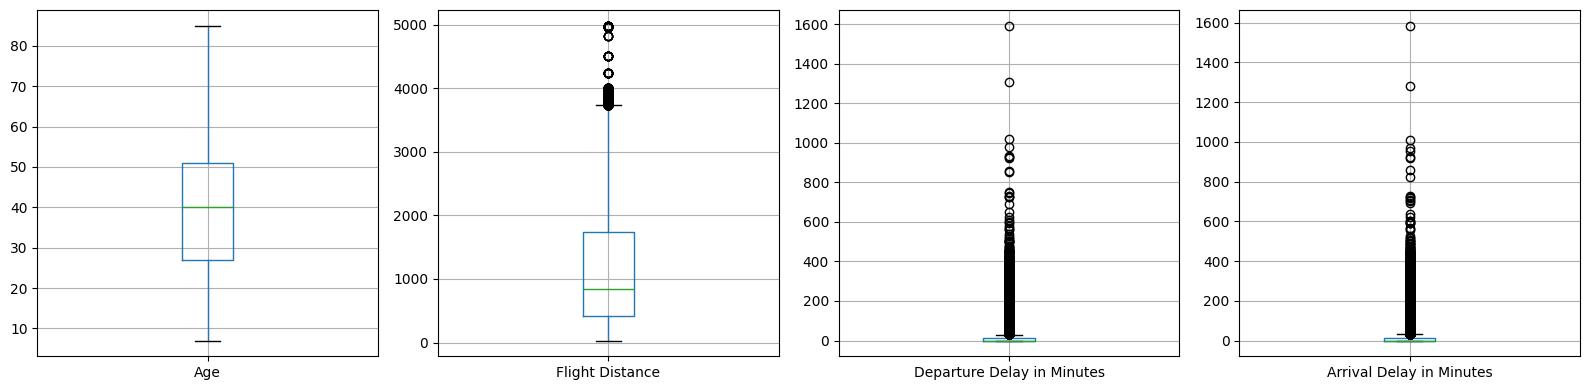

In [18]:
# 19. Boxplot delle variabili continue, per avere un'idea visiva prima del calcolo
continuous_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, continuous_cols):
    train.boxplot(column=col, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
# 20. Metodo IQR (Interquartile Range): un valore è outlier se cade fuori dall'intervallo
#     [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. È il metodo standard legato al boxplot, robusto perché
#     basato sui quartili e non "trascinato" dai valori estremi come farebbero media/deviazione standard.

def iqr_outlier_report(df, cols):
    report = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct = n_outliers / len(df) * 100
        report[col] = {
            'lower_bound': lower, 'upper_bound': upper,
            'n_outliers': n_outliers, 'pct_outliers': round(pct, 2)
        }
    return pd.DataFrame(report).T

iqr_outlier_report(train, continuous_cols)

,lower_bound,upper_bound,n_outliers,pct_outliers
Age,-9.0,87.0,0.0,0.00
Flight Distance,-1579.5,3736.5,2291.0,2.20
Departure Delay in Minutes,-18.0,30.0,14529.0,13.98
Arrival Delay in Minutes,-19.5,32.5,14052.0,13.52


Applicando il metodo IQR alle variabili continue, `Age` non presenta outlier (0%) e `Flight Distance` ne ha una quota contenuta (2.20%), verosimilmente voli a lungo raggio. `Departure Delay in Minutes` e `Arrival Delay in Minutes` mostrano invece una percentuale elevata (13.98% e 13.52%), dovuta alla forte asimmetria della loro distribuzione: essendo la maggior parte dei valori concentrata vicino allo zero, l'intervallo interquartile è molto stretto e il metodo finisce per etichettare come "outlier" anche ritardi solo moderati, non solo casi estremi. Si tratta comunque di valori reali e plausibili, non di errori di misurazione.

Data la numerosità (circa il 14% delle righe) e la natura genuina di questi valori, si è scelto di **non rimuovere** alcuna osservazione: eliminarle introdurrebbe una perdita di dati importante e un bias sistematico verso i voli più regolari. Si terrà comunque conto di questa asimmetria nella fase di standardizzazione, valutando l'uso di uno scaler più robusto agli outlier per queste due variabili.

## Ricerca di multicollinearità

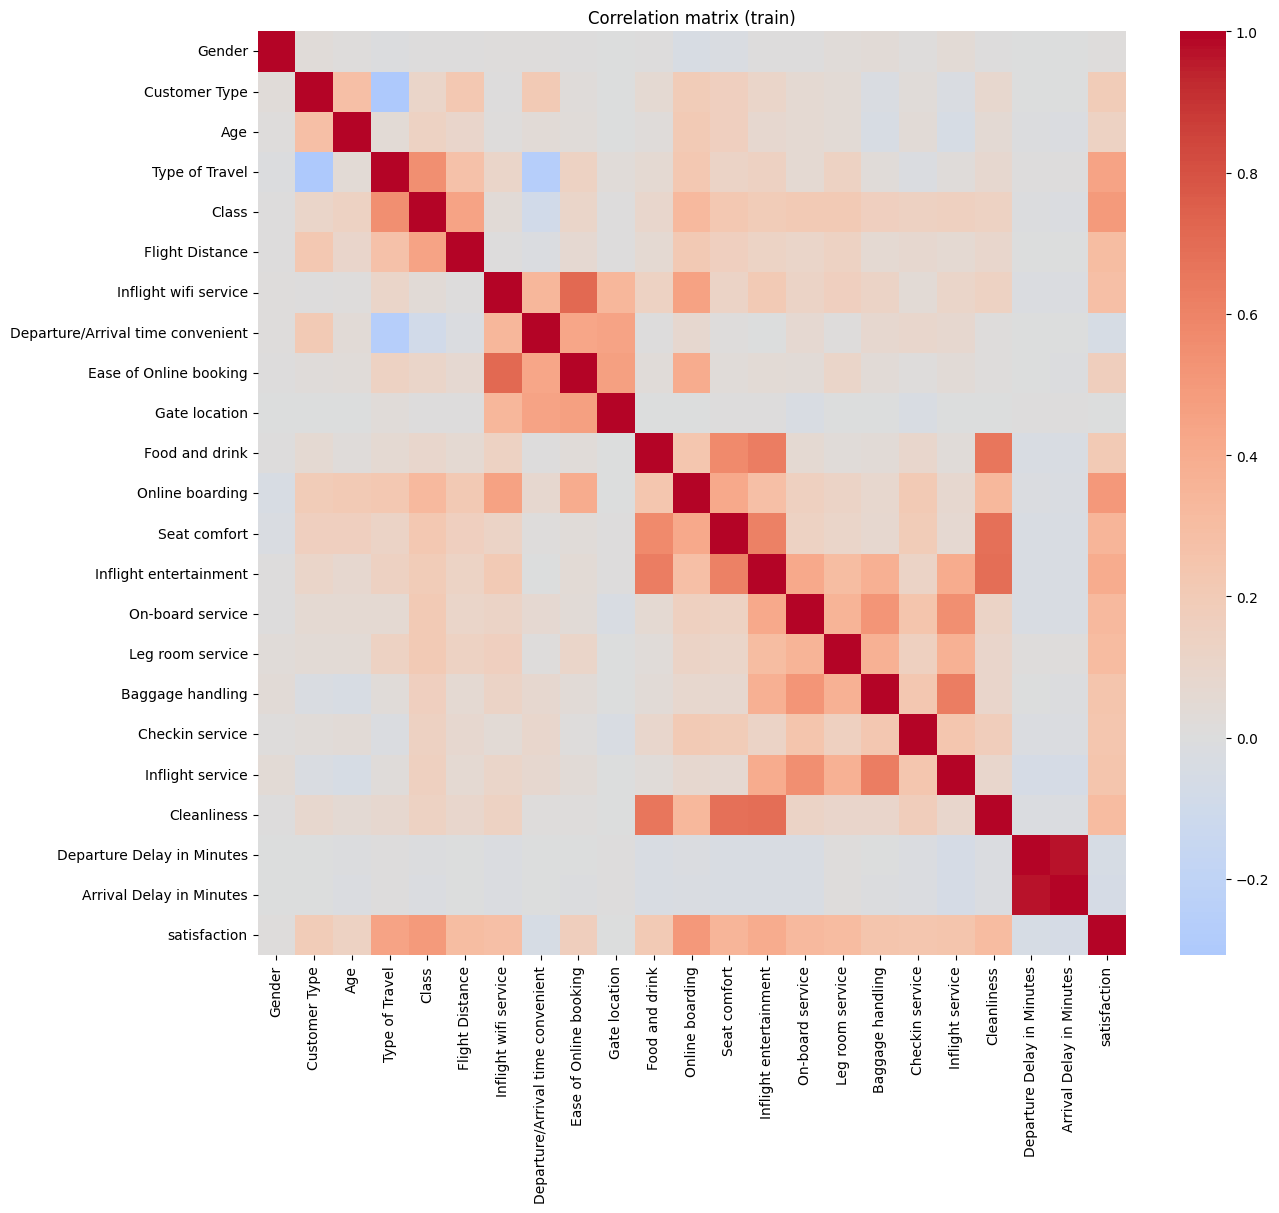

In [20]:
# 21. Correlation matrix (Pearson) su tutte le variabili del train, target incluso per riferimento
corr_matrix = train.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation matrix (train)')
plt.show()

In [21]:
# 22. Il target viene escluso: qui si cerca la ridondanza tra le feature, non la loro relazione col target.
feature_corr = corr_matrix.drop(index=target, columns=target)

# Si considera solo il triangolo superiore per non contare due volte la stessa coppia (A,B) e (B,A)
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'].abs() > 0.9].sort_values('correlation', key=abs, ascending=False)

high_corr_pairs

,feature_1,feature_2,correlation
461,Departure Delay in Minutes,Arrival Delay in Minutes,0.965782


In [22]:
# 23. Solo come anteprima informale: come si correlano le feature col target?
#     La vera selezione delle feature avviene nel prossimo step.
corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

Online boarding                      0.503557
Class                                0.494471
Type of Travel                       0.449000
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Customer Type                        0.187638
Ease of Online booking               0.171705
Age                                  0.137167
Arrival Delay in Minutes            -0.057522
Departure/Arrival time convenient   -0.051601
Departure Delay in Minutes          -0.050494
Gender                               0.012211
Gate location                     

In [23]:
# 24. Soglia abbassata per vedere anche le correlazioni moderate-forti tra le feature
#     (relazioni comunque rilevanti tra alcune variabili di servizio)

moderate_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
)
moderate_corr_pairs = moderate_corr_pairs[moderate_corr_pairs['correlation'].abs() > 0.5].sort_values('correlation', key=abs, ascending=False)
moderate_corr_pairs

,feature_1,feature_2,correlation
461,Departure Delay in Minutes,Arrival Delay in Minutes,0.965782
140,Inflight wifi service,Ease of Online booking,0.715856
305,Inflight entertainment,Cleanliness,0.691815
283,Seat comfort,Cleanliness,0.678534
239,Food and drink,Cleanliness,0.657760
370,Baggage handling,Inflight service,0.628561
233,Food and drink,Inflight entertainment,0.622512
277,Seat comfort,Inflight entertainment,0.610590
232,Food and drink,Seat comfort,0.574556
326,On-board service,Inflight service,0.550782


### Correlazione e multicollinearità

Dalla correlation matrix emerge un solo caso di correlazione molto alta tra feature: `Departure Delay in Minutes` e `Arrival Delay in Minutes` (r = 0.966). Non si tratta di una correlazione perfetta (r = 1) come richiesto dal brief per parlare di multicollinearità in senso stretto, ma è comunque un segnale forte di ridondanza informativa tra le due variabili, coerente con quanto osservato già in fase di gestione dei missing values.

Abbassando la soglia a 0.5 emergono altre correlazioni moderate, che riflettono due gruppi coerenti di variabili: uno legato al comfort/esperienza di viaggio (`Inflight entertainment`, `Seat comfort`, `Food and drink`, `Cleanliness`, r tra 0.57 e 0.69) e uno legato al servizio del personale (`Baggage handling`, `Inflight service`, `On-board service`, r tra 0.52 e 0.63). È plausibile un "effetto alone": chi valuta positivamente un aspetto del volo tende a valutare positivamente anche gli altri. Nessuna di queste correlazioni è però abbastanza estrema da richiedere l'eliminazione di variabili solo su questa base: la vera selezione delle feature verrà fatta con test statistici dedicati nel prossimo step.

---

## Selezione delle feature


### Chi-square test

In [24]:
# 25. Preparazione X (tutte le feature, target escluso) e y (il target), lavorando solo sul train
X = train.drop(columns=[target])
y = train[target]

print(X.shape, y.shape)
print(X.columns.tolist())

(103904, 22) (103904,)
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [25]:
# 26. Verifica preliminare: il Chi-square richiede valori non negativi
print("Valore minimo in tutto X (deve essere >= 0):", X.min().min())

Valore minimo in tutto X (deve essere >= 0): 0.0


In [26]:
# 27. Chi-square test tra ogni feature e il target

chi2_stats, chi2_pvalues = chi2(X, y)

chi2_results = pd.DataFrame({
    'feature': X.columns,
    'chi2_stat': chi2_stats,
    'p_value': chi2_pvalues
}).sort_values('chi2_stat', ascending=False)

chi2_results

,feature,chi2_stat,p_value
5,Flight Distance,7.753602e+06,0.000000e+00
21,Arrival Delay in Minutes,3.396459e+04,0.000000e+00
20,Departure Delay in Minutes,2.613488e+04,0.000000e+00
4,Class,2.290858e+04,0.000000e+00
11,Online boarding,1.476196e+04,0.000000e+00
2,Age,1.134151e+04,0.000000e+00
13,Inflight entertainment,8.711182e+03,0.000000e+00
3,Type of Travel,6.501444e+03,0.000000e+00
12,Seat comfort,6.419260e+03,0.000000e+00
6,Inflight wifi service,5.422334e+03,0.000000e+00


Il Chi-square test misura quanto ogni feature sia associata al target. Guardando la tabella dei risultati, però, emerge subito un limite del metodo così applicato: il `chi2_stat` di `Flight Distance` (≈7.75 milioni) è ordini di grandezza più alto di quello delle feature di rating (che vanno da 0 a 5, con chi2_stat nell'ordine delle migliaia). Questo non riflette necessariamente una reale maggiore importanza: il Chi-square calcolato da sklearn **non è invariante alla scala** dei dati, quindi feature con range di valori assoluti molto più ampi (Flight Distance, Departure/Arrival Delay, tutte con valori fino alle migliaia) tendono meccanicamente a produrre statistiche più alte rispetto a feature limitate (0-5 o 0/1), a prescindere dal loro reale potere predittivo. Per questo motivo non verrà usato solo il `chi2_stat` per stabilire una classifica di importanza, ma verrà confrontato con Mutual Information e T-test.

Va inoltre notato che, con oltre 100.000 osservazioni nel train, quasi tutte le feature risultano statisticamente significative (p-value vicinissimo a 0): è un effetto tipico della numerosità campionaria elevata, per cui anche relazioni molto deboli diventano significative. L'unica feature che si distingue chiaramente per la sua irrilevanza è `Gate location`, con un p-value di 0.87 — nettamente non significativo, e quindi una prima candidata all'esclusione.

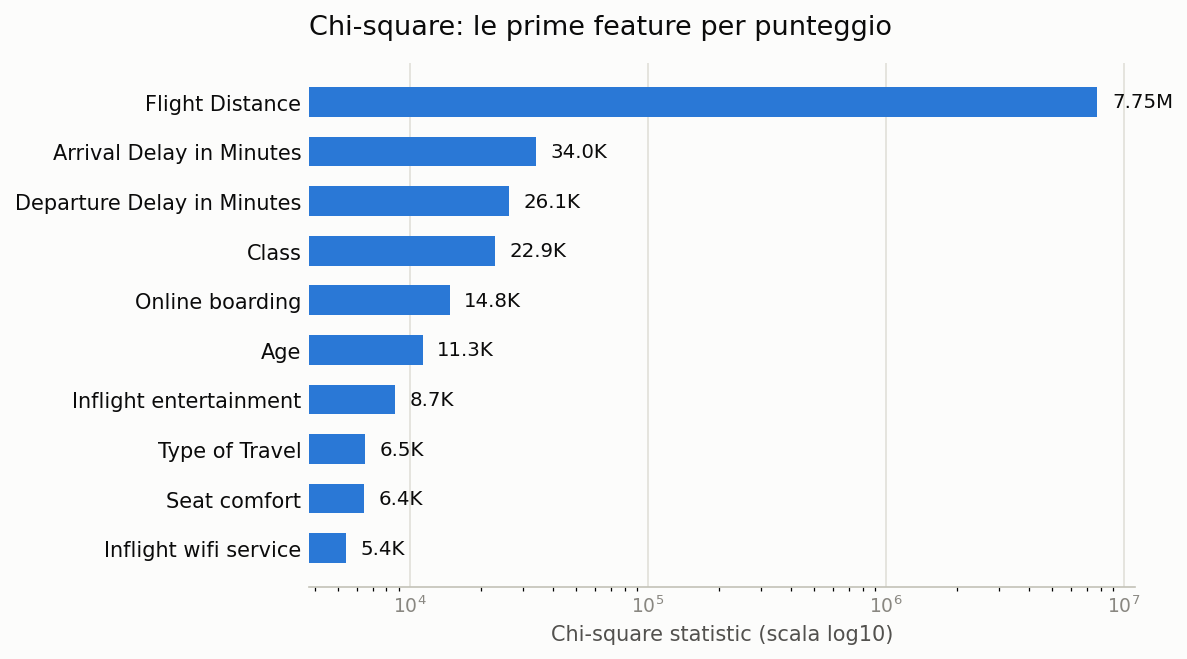

In [27]:
# 27b. Bar chart Chi-square (scala log10) con etichette del valore reale
import matplotlib.pyplot as plt

top_n = 10
chi2_top = chi2_results.sort_values('chi2_stat', ascending=False).head(top_n).iloc[::-1]

def format_value(v):
    if v >= 1_000_000:
        return f"{v/1_000_000:.2f}M"
    elif v >= 1_000:
        return f"{v/1_000:.1f}K"
    return f"{v:.1f}"

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

bars = ax.barh(chi2_top['feature'], chi2_top['chi2_stat'], color='#2a78d6', height=0.6, zorder=3)

ax.set_xscale('log')
ax.set_xlabel('Chi-square statistic (scala log10)', color='#52514e', fontsize=10)
ax.set_title('Chi-square: le prime feature per punteggio', color='#0b0b0b', fontsize=13, loc='left', pad=14)

ax.grid(axis='x', which='major', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')

ax.tick_params(axis='y', length=0, labelsize=10, colors='#0b0b0b')
ax.tick_params(axis='x', length=0, labelsize=9, colors='#898781')

for bar, val in zip(bars, chi2_top['chi2_stat']):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            format_value(val), va='center', ha='left', fontsize=9.5, color='#0b0b0b')

plt.tight_layout()
plt.savefig('chi2_top_features.png', dpi=200, bbox_inches='tight', facecolor='#fcfcfb')
plt.show()

### Mutual Information

In [28]:
# 28. Mutual Information: misura la dipendenza (anche non lineare) tra ogni feature e il target,
#     senza essere influenzata dalla scala della variabile come invece succede al Chi-square.

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

mi_results

,feature,mi_score
11,Online boarding,0.212467
6,Inflight wifi service,0.161353
4,Class,0.142488
3,Type of Travel,0.123745
13,Inflight entertainment,0.096520
12,Seat comfort,0.085367
5,Flight Distance,0.065787
15,Leg room service,0.064208
14,On-board service,0.060573
19,Cleanliness,0.058157


I risultati della Mutual Information confermano in modo netto il sospetto sollevato commentando il Chi-square: `Flight Distance` crolla dalla prima alla settima posizione, e `Departure Delay in Minutes` / `Arrival Delay in Minutes` — rispettivamente 2° e 3° nel Chi-square — finiscono quasi ultime (score 0.0077 e 0.0054, terzultima e penultima posizione su 22). La Mutual Information non è influenzata dalla scala dei valori assoluti come il Chi-square, quindi questo si può considerare un chiaro segnale che l'alto punteggio di quelle tre variabili nel Chi-square fosse un artefatto della loro scala, non un riflesso della reale importanza predittiva.

Le feature che emergono come più informative sono `Online boarding` (0.212), `Inflight wifi service` (0.161), `Class` (0.142) e `Type of Travel` (0.124) — tutte confermate anche dal Chi-square, quindi possono essere considerate candidate solide.

`Gate location` conferma la sua scarsa utilità (score 0.016, coerente con il p-value non significativo del Chi-square), mentre `Departure/Arrival time convenient` risulta addirittura la feature meno informativa in assoluto (0.0046) nonostante un p-value "significativo" nel Chi-square — ulteriore conferma che, con un campione di oltre 100.000 osservazioni, la significatività statistica da sola non basta a stabilire la rilevanza pratica di una feature.

#### Verifica di un'ipotesi: il ritardo conta più "a soglia" che in modo continuo?

Il punteggio di Mutual Information molto basso ottenuto da `Departure Delay in Minutes` e `Arrival Delay in Minutes` è sorprendente, perché ci si aspetterebbe che la puntualità sia un fattore rilevante per la soddisfazione di un passeggero. Una possibile spiegazione è che l'effetto del ritardo non sia lineare rispetto ai minuti: forse un passeggero nota (e vede penalizzata la propria soddisfazione) solo quando il ritardo supera una certa soglia percepibile, mentre ritardi minimi vengono dati per scontati o non fanno differenza. Se è così, codificare il ritardo come valore continuo in minuti potrebbe diluire un segnale che invece emergerebbe più chiaramente con una codifica a soglie.

Si verifica l'ipotesi ricodificando il ritardo in tre fasce, usando i 15 minuti come soglia di puntualità (lo standard comunemente adottato nel settore aereo per considerare un volo in orario): nessun ritardo rilevante (≤15 minuti), ritardo moderato (16-60 minuti) e ritardo severo (oltre 60 minuti). Si ricalcola la Mutual Information su questa nuova versione e la si confronta con quella della variabile continua originale.

In [29]:
# 29. Ricodifica del ritardo in categorie (soglia di puntualità = 15 minuti, standard di settore)
#     e confronto con la Mutual Information della versione a soglie con quella continua originale.

def bucket_delay(minutes):
    bins = [-1, 15, 60, np.inf]          # -1 per includere anche lo 0 nel primo bin
    labels = [0, 1, 2]                    # 0 = in orario, 1 = ritardo moderato, 2 = ritardo severo
    return pd.cut(minutes, bins=bins, labels=labels).astype(int)

departure_bucket = bucket_delay(train['Departure Delay in Minutes'])
arrival_bucket = bucket_delay(train['Arrival Delay in Minutes'])

comparison_df = pd.DataFrame({
    'Departure Delay in Minutes (continua)': train['Departure Delay in Minutes'],
    'Arrival Delay in Minutes (continua)': train['Arrival Delay in Minutes'],
    'Departure Delay bucket': departure_bucket,
    'Arrival Delay bucket': arrival_bucket,
})

mi_comparison = mutual_info_classif(comparison_df, y, random_state=42)

pd.DataFrame({
    'feature': comparison_df.columns,
    'mi_score': mi_comparison
}).sort_values('mi_score', ascending=False)

,feature,mi_score
1,Arrival Delay in Minutes (continua),0.006979
2,Departure Delay bucket,0.004869
3,Arrival Delay bucket,0.003320
0,Departure Delay in Minutes (continua),0.001668


Per Departure Delay, la versione a bucket (0.0049) è effettivamente più alta di quella continua (0.0017), ma per Arrival Delay succede il contrario: la versione continua (0.0070) resta più alta di quella a bucket (0.0033). Quindi l'effetto soglia non si conferma in modo consistente tra le due variabili. Inoltre anche il valore più alto di questo gruppo (0.0070) resta un ordine di grandezza sotto le feature più informative come Online boarding (0.212). Quindi l'ipotesi non trova conferma nei dati.

Si effettua un ultimo controllo cercando la quota di soddisfatti per fascia di ritardo.

In [30]:
# 30. Controllo intuitivo: quota di soddisfatti per fascia di ritardo
for name, bucket in [('Departure Delay', departure_bucket), ('Arrival Delay', arrival_bucket)]:
    print(f"--- {name} ---")
    summary = pd.DataFrame({
        'quota_soddisfatti': train.groupby(bucket)[target].mean(),
        'n_osservazioni': train.groupby(bucket)[target].count()
    })
    print(summary)
    print()

--- Departure Delay ---
                            quota_soddisfatti  n_osservazioni
Departure Delay in Minutes                                   
0                                    0.451776           80852
1                                    0.373806           15813
2                                    0.357370            7239

--- Arrival Delay ---
                          quota_soddisfatti  n_osservazioni
Arrival Delay in Minutes                                   
0                                  0.456366           80133
1                                  0.354910           16376
2                                  0.357404            7395



**Conclusione sulla verifica dell'ipotesi**

L'analisi della quota di soddisfatti per fascia di ritardo conferma parzialmente l'ipotesi iniziale, ma in una forma più precisa di quanto ipotizzato: il passaggio da "nessun ritardo" a "ritardo anche solo moderato" comporta un calo netto della soddisfazione (dal 45-46% al 35-37%, circa 10 punti percentuali), mentre tra ritardo moderato e severo la quota di soddisfatti resta sostanzialmente invariata. Il ritardo, quindi, sembra avere un effetto a soglia più che proporzionale ai minuti: ciò che conta è che il volo sia o meno in orario, non di quanto sfori.

Questo spiega perché la Mutual Information calcolata sull'intero dataset assegni a queste variabili un punteggio basso pur in presenza di un effetto individuale reale: il fenomeno riguarda solo circa il 22% dei passeggeri, mentre le feature con MI più alta (es. `Online boarding`, `Inflight wifi service`) variano per la quasi totalità del campione. La Mutual Information misura quanta informazione una variabile porta sull'intera popolazione, non l'intensità dell'effetto per chi è coinvolto nel fenomeno. In conclusione, la puntualità resta un fattore secondario nella capacità predittiva complessiva rispetto ai servizi digitali/di bordo valutati da tutti i passeggeri, ma non è affatto irrilevante per chi la subisce.

### Il T-test

In [31]:
# 31. T-test per campioni indipendenti: confronta la media di ogni feature tra il gruppo
#     "satisfied" e il gruppo "neutral or dissatisfied". Si usa la variante di Welch
#     (equal_var=False), che non assume varianze uguali tra i due gruppi ed è generalmente
#     la scelta più robusta di default quando non è noto a priori.

group0 = train[y == 0]  # neutral or dissatisfied
group1 = train[y == 1]  # satisfied

ttest_results = []
for col in X.columns:
    t_stat, p_value = stats.ttest_ind(group0[col], group1[col], equal_var=False)
    ttest_results.append({'feature': col, 't_stat': t_stat, 'abs_t_stat': abs(t_stat), 'p_value': p_value})

ttest_df = pd.DataFrame(ttest_results).sort_values('abs_t_stat', ascending=False)
ttest_df

,feature,t_stat,abs_t_stat,p_value
11,Online boarding,-186.897164,186.897164,0.000000e+00
4,Class,-185.542096,185.542096,0.000000e+00
3,Type of Travel,-174.899190,174.899190,0.000000e+00
13,Inflight entertainment,-143.714775,143.714775,0.000000e+00
12,Seat comfort,-122.345249,122.345249,0.000000e+00
14,On-board service,-111.710982,111.710982,0.000000e+00
15,Leg room service,-107.744576,107.744576,0.000000e+00
19,Cleanliness,-105.365531,105.365531,0.000000e+00
5,Flight Distance,-96.423615,96.423615,0.000000e+00
6,Inflight wifi service,-89.854686,89.854686,0.000000e+00


### Confronto finale


In [32]:
# 32. Confronto finale: rank di ogni feature nei tre metodi (1 = più rilevante)
chi2_results['chi2_rank'] = chi2_results['chi2_stat'].rank(ascending=False).astype(int)
mi_results['mi_rank'] = mi_results['mi_score'].rank(ascending=False).astype(int)
ttest_df['ttest_rank'] = ttest_df['abs_t_stat'].rank(ascending=False).astype(int)

comparison = (
    ttest_df[['feature', 'abs_t_stat', 'p_value', 'ttest_rank']]
    .merge(mi_results[['feature', 'mi_score', 'mi_rank']], on='feature')
    .merge(chi2_results[['feature', 'chi2_stat', 'chi2_rank']], on='feature')
    .sort_values('ttest_rank')
)
comparison

,feature,abs_t_stat,p_value,ttest_rank,mi_score,mi_rank,chi2_stat,chi2_rank
0,Online boarding,186.897164,0.000000e+00,1,0.212467,1,1.476196e+04,5
1,Class,185.542096,0.000000e+00,2,0.142488,3,2.290858e+04,4
2,Type of Travel,174.899190,0.000000e+00,3,0.123745,4,6.501444e+03,8
3,Inflight entertainment,143.714775,0.000000e+00,4,0.096520,5,8.711182e+03,7
4,Seat comfort,122.345249,0.000000e+00,5,0.085367,6,6.419260e+03,9
5,On-board service,111.710982,0.000000e+00,6,0.060573,9,5.299337e+03,11
6,Leg room service,107.744576,0.000000e+00,7,0.064208,8,5.261977e+03,12
7,Cleanliness,105.365531,0.000000e+00,8,0.058157,10,5.071376e+03,13
8,Flight Distance,96.423615,0.000000e+00,9,0.065787,7,7.753602e+06,1
9,Inflight wifi service,89.854686,0.000000e+00,10,0.161353,2,5.422334e+03,10


**Confronto finale: Chi-square, Mutual Information, T-test**

Mettendo a confronto i tre metodi emerge un quadro coerente e allo stesso tempo istruttivo sui limiti di ciascuno.

**Convergenza sulle feature più rilevanti.** `Online boarding`, `Class`, `Type of Travel`, `Inflight entertainment` e `Seat comfort` occupano le prime posizioni sia nel T-test sia nella Mutual Information, due metodi concettualmente molto diversi (il primo confronta le medie tra gruppi, il secondo misura la dipendenza statistica generale) che convergono sulle stesse variabili. Questo dà fiducia che si tratti di feature realmente informative, non di un artefatto di un singolo metodo.

**Il Chi-square va usato con cautela sulle variabili a scala ampia.** Il confronto conferma quanto sospettato in precedenza: `Flight Distance` è 1° nel Chi-square ma solo 9° nel T-test e 7° nella Mutual Information; `Arrival Delay in Minutes` e `Departure Delay in Minutes` sono rispettivamente 2° e 3° nel Chi-square, ma crollano quasi in fondo alla classifica (18°-20°) sia nel T-test sia nella MI. Il Chi-square, non essendo invariante alla scala dei dati, sovrastima sistematicamente le variabili con range di valori assoluti più ampio: da solo sarebbe stato fuorviante.

**Feature da escludere.** `Gate location` è inequivocabilmente la meno rilevante su tutti e tre i test (ultima o penultima posizione ovunque, p-value non significativo nel Chi-square e nel T-test). `Gender` è anch'essa costantemente in fondo alla classifica, pur risultando statisticamente significativa nel T-test (p < 0.0001): con oltre 100.000 osservazioni anche un effetto minimo diventa significativo, motivo per cui si preferisce guardare l'ampiezza del t-statistic più che il solo p-value.

**Selezione per la "strada 2" (feature selection).** Si selezionano le feature con il t-statistic più alto (in valore assoluto) nel T-test, quindi le prime 4: **Online boarding, Class, Type of Travel, Inflight entertainment**. La scelta è ulteriormente rafforzata dal fatto che tutte e 4 rientrano anche nelle prime 5 posizioni della Mutual Information, quindi il segnale è confermato da due metodi indipendenti.

---

## Standardizzazione

In [33]:
# 33. Standardizzazione delle feature.
#     RobustScaler per le due colonne di ritardo (fortemente skewed, come visto nell'analisi
#     outlier), StandardScaler per tutte le altre. Fit SOLO sul train, per non introdurre
#     data leakage: il test viene solo trasformato con i parametri già imparati dal train.


robust_cols = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']
standard_cols = [c for c in X.columns if c not in robust_cols]

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

robust_scaler.fit(train[robust_cols])
standard_scaler.fit(train[standard_cols])

train_scaled = train.copy()
test_scaled = test.copy()

train_scaled[robust_cols] = robust_scaler.transform(train[robust_cols])
test_scaled[robust_cols] = robust_scaler.transform(test[robust_cols])

train_scaled[standard_cols] = standard_scaler.transform(train[standard_cols])
test_scaled[standard_cols] = standard_scaler.transform(test[standard_cols])

# Il target resta invariato
train_scaled[target] = train[target]
test_scaled[target] = test[target]

train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,103904.0,-4.157780e-17,1.000005,-0.985192,-0.985192,-0.985192,1.015031,1.015031
Customer Type,103904.0,-3.473935e-17,1.000005,-2.115208,0.472767,0.472767,0.472767,0.472767
Age,103904.0,-8.753221e-18,1.000005,-2.142239,-0.819040,0.041039,0.768798,3.018235
Type of Travel,103904.0,3.973142e-17,1.000005,-1.490614,-1.490614,0.670865,0.670865,0.670865
Class,103904.0,-3.747473e-17,1.000005,-1.067767,-1.067767,-0.029187,1.009393,1.009393
Flight Distance,103904.0,8.042022e-17,1.000005,-1.161768,-0.777671,-0.347441,0.555138,3.804423
Inflight wifi service,103904.0,6.024678e-17,1.000005,-2.055758,-0.549533,0.203579,0.956691,1.709804
Departure/Arrival time convenient,103904.0,-1.620714e-16,1.000005,-2.006662,-0.695245,-0.039537,0.616172,1.271880
Ease of Online booking,103904.0,1.427869e-16,1.000005,-1.970731,-0.541060,0.173776,0.888612,1.603448
Gate location,103904.0,3.638058e-17,1.000005,-2.330031,-0.764614,0.018094,0.800803,1.583511


In [34]:
# 34. Verifica: sulle colonne StandardScaler, media ≈ 0 e deviazione standard ≈ 1 SUL TRAIN.
#     Sul test non sarà così perfetto, ma va bene perché il test non deve definire la scala.
print("Medie (train):")
print(train_scaled[standard_cols].mean().round(3))
print("\nDeviazioni standard (train):")
print(train_scaled[standard_cols].std().round(3))

Medie (train):
Gender                              -0.0
Customer Type                       -0.0
Age                                 -0.0
Type of Travel                       0.0
Class                               -0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient   -0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                     -0.0
Seat comfort                        -0.0
Inflight entertainment              -0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                    -0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                         -0.0
dtype: float64

Deviazioni standard (train):
Gender                               1.0
Customer Type                        1.0
Age                                  1

Le feature sono state standardizzate con due approcci diversi in base a quanto emerso nell'analisi precedente: `StandardScaler` per la maggior parte delle variabili (media 0, deviazione standard 1 sul train, verificato sopra), `RobustScaler` per `Departure Delay in Minutes` e `Arrival Delay in Minutes`, data la loro forte asimmetria (skewness 6.6) e la presenza di valori estremi. Su queste due colonne il RobustScaler porta la mediana a 0 e l'IQR a 1, ma lascia intatta la presenza di valori estremi nella coda, comportamento corretto e coerente con la scelta di non eliminare gli outlier. In tutti i casi gli scaler sono stati fittati solo sul train e poi applicati al test, per evitare data leakage. Il target `satisfaction` non è mai stato toccato dalla standardizzazione.

---

## Scelta della metrica di valutazione
Si tratta di un problema di **classificazione binaria**: prevedere se un passeggero è `satisfied` oppure `neutral or dissatisfied`. Prima di allenare qualsiasi modello è importante stabilire con quale criterio se ne misureranno le prestazioni.

Alla base di (quasi) tutte le metriche di classificazione c'è la **confusion matrix**, che conta quante osservazioni cadono nelle quattro combinazioni possibili tra classe reale e classe prevista: veri positivi (TP), veri negativi (TN), falsi positivi (FP) e falsi negativi (FN). In questo caso si definisce "positiva" la classe `satisfied` (1). Si tratta solo di una convenzione, ma, come si vedrà a breve, alcune metriche dipendono da questa scelta.

**Accuracy** = (TP + TN) / totale osservazioni. È la percentuale di previsioni corrette sul totale. Il suo limite è che non distingue tra le classi: un classificatore "banale" che prevede sempre la classe maggioritaria ottiene comunque un'accuracy del 56.67% senza aver imparato nulla dai dati.

**Precision** = TP / (TP + FP). Di tutti i passeggeri che il modello prevede come soddisfatti, quanti lo sono davvero. È utile quando il costo di un falso positivo è alto (es. considerare "risolto" un cliente che in realtà non lo è).

**Recall** (o Sensitivity/True Positive Rate) = TP / (TP + FN). Di tutti i passeggeri realmente soddisfatti, quanti il modello riesce a individuare correttamente. Speculare: la **Specificity** = TN / (TN + FP) fa lo stesso ragionamento per la classe negativa (identificare correttamente i clienti insoddisfatti). In un contesto reale come questo, un'azienda potrebbe essere particolarmente interessata alla recall sulla classe "dissatisfied", per non perdere di vista i clienti scontenti su cui intervenire.

**F1-score** = media armonica di Precision e Recall = 2·(P·R)/(P+R). Condensa in un solo numero il compromesso tra le due, ed è più informativo dell'accuracy quando le classi sono sbilanciate, perché un modello che ignora sistematicamente la classe minoritaria viene penalizzato. Come precision e recall, però, dipende da quale classe è considerata positiva.

**Balanced accuracy** = (Recall + Specificity) / 2. È la media delle recall delle due classi: dà lo stesso peso alla capacità di riconoscere i soddisfatti e a quella di riconoscere gli insoddisfatti, indipendentemente da quanto è numerosa ciascuna classe. Qualunque classificatore che non sfrutti i dati (che preveda sempre la stessa classe o che tiri a caso) ottiene 0.5, a prescindere da quale classe sia considerata positiva.

**ROC-AUC** (Area Under the ROC Curve): la curva ROC mette in relazione True Positive Rate e False Positive Rate al variare della soglia di decisione del classificatore (di solito 0.5, ma può essere spostata); l'AUC riassume in un solo numero (0.5 = casuale, 1 = perfetto) quanto il modello sa separare le due classi, indipendentemente dalla soglia.

**Matthews Correlation Coefficient (MCC)**: coefficiente di correlazione tra classi reali e classi previste, calcolato usando tutte e quattro le celle della confusion matrix. Va da -1 a +1 (0 = nessuna capacità predittiva, 1 = previsione perfetta), è simmetrico rispetto alle due classi ed è considerato una delle misure di sintesi più affidabili per la classificazione binaria.

Esistono altre metriche (es. la Log Loss, che valuta la qualità delle probabilità stimate), non utilizzate in questo progetto.

### La scelta: accuracy come metrica principale
Come indicato dal brief, per confrontare e selezionare i modelli si usa l'**accuracy**. In questo caso la scelta è anche giustificata dai dati:
- lo sbilanciamento del target è lieve (56.67% / 43.33%), quindi l'accuracy non è dominata dalla classe maggioritaria, come accadrebbe invece con proporzioni del tipo 95/5;
- non ci sono elementi per attribuire costi molto diversi ai due tipi di errore. In un'applicazione reale un falso negativo sulla classe "dissatisfied" (un cliente scontento non individuato) potrebbe costare più di un falso positivo, ma senza informazioni di business non è possibile quantificarlo.

Per non affidarsi a un solo numero, accanto all'accuracy verranno comunque riportate **balanced accuracy, F1-score, ROC-AUC e MCC**, sia in cross validation sia sul test set finale. Queste metriche non verranno usate per selezionare i modelli, ma come controllo: se la classifica dei modelli resta la stessa anche con queste metriche, la scelta dell'accuracy ne esce rafforzata.

In [35]:
# 35. Calcolo delle metriche definite sopra sul classificatore "banale" (predice sempre 0),
#     per vedere in pratica quanto l'accuracy da sola possa essere fuorviante.

y_true = y  # target del train
y_baseline_pred = np.zeros_like(y_true)  # predice sempre "neutral or dissatisfied"

print("Confusion matrix:\n", confusion_matrix(y_true, y_baseline_pred))
print("\nAccuracy:", accuracy_score(y_true, y_baseline_pred))
print("Precision (classe 'satisfied'):", precision_score(y_true, y_baseline_pred, zero_division=0))
print("Recall (classe 'satisfied'):", recall_score(y_true, y_baseline_pred, zero_division=0))
print("F1-score (classe 'satisfied'):", f1_score(y_true, y_baseline_pred, zero_division=0))

# Stesso classificatore, ma considerando positiva la classe 'neutral or dissatisfied' (0):
# l'F1-score cambia completamente, la balanced accuracy no.
print("\nF1-score (classe 'neutral or dissatisfied' come positiva):", f1_score(y_true, y_baseline_pred, pos_label=0))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_baseline_pred))

Confusion matrix:
 [[58879     0]
 [45025     0]]

Accuracy: 0.5666673082845703
Precision (classe 'satisfied'): 0.0
Recall (classe 'satisfied'): 0.0
F1-score (classe 'satisfied'): 0.0

F1-score (classe 'neutral or dissatisfied' come positiva): 0.7234047781402235
Balanced accuracy: 0.5


### Interpretazione della baseline

I risultati confermano concretamente il limite dell'accuracy discusso sopra. Il classificatore banale ottiene un'accuracy del 56.67%, che potrebbe sembrare un punto di partenza già decente, ma la confusion matrix rivela la realtà: tutte le 45.025 osservazioni della classe "satisfied" vengono classificate come "neutral or dissatisfied" (0 veri positivi), portando precision, recall e F1-score per quella classe a 0. Questo modello non ha quindi alcuna capacità predittiva reale: si limita a sfruttare lo squilibrio delle classi (56.67%/43.33%) senza aver imparato nulla dai dati.

Va però notato che l'F1-score nullo dipende dalla convenzione adottata: se si considerasse positiva la classe "neutral or dissatisfied", lo stesso classificatore avrebbe recall pari a 1 e un F1-score di 0.72, un valore in apparenza buono. La balanced accuracy vale invece 0.5 in entrambi i casi: è la metrica che mette meglio in evidenza l'assenza di capacità predittiva, senza dipendere dalla scelta della classe positiva.

### Baseline di riferimento

Il classificatore banale fissa il livello minimo, ma da solo è un termine di paragone poco esigente: quasi qualunque modello lo supera. Per avere un riferimento più informativo si confrontano tre baseline di complessità crescente, valutate con la stessa procedura che verrà usata per i modelli (k-fold cross validation stratificata a 5 fold, solo sul train; il test set resta inutilizzato):

- **Dummy - classe maggioritaria**: prevede sempre "neutral or dissatisfied" (il classificatore visto sopra);
- **Dummy - casuale stratificato**: prevede a caso, rispettando le proporzioni delle classi del train;
- **Regola su una sola feature**: un albero di decisione di profondità 1 (*decision stump*) addestrato solo su `Online boarding`, la feature risultata più rilevante sia nel T-test sia nella Mutual Information. Equivale a una regola del tipo "se il voto all'online boarding supera una certa soglia, il passeggero è soddisfatto", cioè al modello più semplice possibile che sfrutta davvero i dati.

L'ultima baseline permette di rispondere a una domanda più utile di "il modello batte il caso?": **quanto aggiungono i modelli più complessi rispetto a una regola elementare?**

In [36]:
# 35b. Baseline valutate con k-fold cross validation, con tutte le metriche definite sopra.
#      Si usa StratifiedKFold invece del KFold semplice per preservare in ogni fold la stessa
#      proporzione di classi del dataset originale (56.67%/43.33%), buona pratica quando le classi
#      non sono perfettamente bilanciate. Lo stesso oggetto cv verrà riusato per spot check e tuning,
#      così che tutti i modelli siano valutati esattamente sugli stessi fold.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metriche calcolate in cross validation (la positiva resta la classe 'satisfied' = 1)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'mcc': make_scorer(matthews_corrcoef),
}

# Convenzione per i nomi delle colonne in tutto il notebook:
#   cv_...        -> metrica in cross validation sul train, modello con parametri di default
#   cv_..._tuned  -> metrica in cross validation sul train, dopo la ricerca degli iperparametri
#   test_...      -> metrica calcolata sul test set (solo nella valutazione finale)

def cv_summary(cv_res):
    """Media sui fold di ogni metrica restituita da cross_validate (colonne con prefisso cv_).
    Nota: sklearn chiama 'test_<metrica>' il punteggio sul fold di validazione della CV,
    non sul test set: per questo i nomi vengono rinominati in 'cv_<metrica>'."""
    return {f'cv_{m}': cv_res[f'test_{m}'].mean() for m in scoring}

baselines = {
    'Dummy - classe maggioritaria': (DummyClassifier(strategy='most_frequent'), X),
    'Dummy - casuale stratificato': (DummyClassifier(strategy='stratified', random_state=42), X),
    'Regola su Online boarding (stump)': (DecisionTreeClassifier(max_depth=1, random_state=42), X[['Online boarding']]),
}

baseline_results = {}
for name, (model, X_b) in baselines.items():
    cv_res = cross_validate(model, X_b, y, cv=cv, scoring=scoring)
    baseline_results[name] = cv_summary(cv_res)

baseline_results = pd.DataFrame(baseline_results).T
display(baseline_results.round(4))

# Soglia scelta dallo stump (addestrato su tutto il train), per leggere la regola in chiaro
stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X[['Online boarding']], y)
print("Soglia appresa su Online boarding:", stump.tree_.threshold[0])

,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_mcc
Dummy - classe maggioritaria,0.5667,0.5000,0.0000,0.5000,0.0000
Dummy - casuale stratificato,0.5105,0.5012,0.4334,0.5012,0.0025
Regola su Online boarding (stump),0.7877,0.7923,0.7715,0.7923,0.5795


Soglia appresa su Online boarding: 3.5


Le due baseline dummy confermano il "pavimento": balanced accuracy e ROC-AUC restano a 0.5 e l'MCC a 0, cioè nessuna capacità predittiva, mentre l'accuracy varia tra il 51% e il 57% solo per effetto delle proporzioni tra le classi. La regola su `Online boarding` (soglia appresa 3.5, cioè voto ≥ 4 → soddisfatto) raggiunge invece già un'accuracy del 78.77% e un MCC di 0.58: una sola domanda del questionario basta a classificare correttamente quasi 4 passeggeri su 5.

Questo cambia il modo di leggere i risultati successivi. Il riferimento minimo resta il 56.67% del classificatore banale, ma il confronto più significativo è con la regola a una feature: un modello più complesso è davvero utile nella misura in cui supera in modo netto il 78.77%, e il margine rispetto a questa regola misura il valore aggiunto dell'uso di più feature e di modelli più flessibili.

---

## Definizione del modello, training e ottimizzazione

Viene ora la fase di modellazione vera e propria. L'obiettivo è addestrare un classificatore in grado di prevedere se un passeggero sarà soddisfatto o meno del volo, confrontando approcci diversi per capire quale funziona meglio. Si seguirà un percorso strutturato in più fasi, ripetuto per due diverse configurazioni di feature ("strada 1" e "strada 2").

- Scelta di almeno 3 modelli di classificazione.
- Definizione di due configurazioni di feature da confrontare: la strada 1 userà tutte le feature disponibili, la strada 2 userà solo le 4 feature risultate più rilevanti nel T-test (`Online boarding`, `Class`, `Type of Travel`, `Inflight entertainment`).
- Per ciascuna delle due strade: uno spot check veloce dei modelli scelti tramite k-fold cross validation, per individuare i due modelli più promettenti senza fare un training completo.
- Ottimizzazione degli iperparametri dei due modelli migliori, tramite ricerca randomizzata (RandomizedSearchCV), sempre valutata con cross validation.
- Valutazione finale dei due modelli ottimizzati sul test set, rimasto finora inutilizzato.
- Confronto tra strada 1 e strada 2 per individuare il modello complessivamente migliore, seguito da una discussione conclusiva sul problema e sulla soluzione trovata.

Come stabilito nella sezione precedente, la selezione dei modelli avviene sull'accuracy, mentre le altre metriche vengono riportate come controllo. Come per l'EDA, ogni scelta verrà motivata passo dopo passo.

### Modelli scelti

Per il task di classificazione binaria sono stati scelti tre modelli, sufficientemente diversi tra loro da rendere interessante il confronto:

- **RandomForestClassifier**: ensemble di alberi allenati in parallelo su campioni bootstrap dei dati (bagging), con voto di maggioranza finale. Robusto agli outlier, non richiede feature scalate.
- **AdaBoostClassifier**: ensemble di weak learner allenati in sequenza (boosting), ciascuno concentrato a correggere gli errori del precedente. Anch'esso non richiede feature scalate, ma è più sensibile agli outlier rispetto al RandomForest.
- **LogisticRegression**: modello lineare che stima la probabilità della classe positiva tramite una funzione logistica. A differenza dei primi due, è sensibile alla scala delle feature, motivo per cui viene usato il dataset standardizzato preparato nell'EDA. È stato preferito a modelli come SVM o KNN per il suo costo computazionale contenuto, importante lavorando su oltre 100.000 osservazioni.

In [37]:
# 36. Preparazione dei due dataset per la modellazione: 'strada 1' con tutte le feature,
#     'strada 2' con solo le 4 più rilevanti dal T-test. Vengono usati i dati già standardizzati
#     (train_scaled / test_scaled): gli alberi non risentono della scala, la Logistic
#     Regression invece sì, quindi lo stesso dataset va bene per tutti e tre i modelli.

selected_features = ['Online boarding', 'Class', 'Type of Travel', 'Inflight entertainment']

# Strada 1: tutte le feature
X_train_full = train_scaled.drop(columns=[target])
y_train_full = train_scaled[target]
X_test_full = test_scaled.drop(columns=[target])
y_test_full = test_scaled[target]

# Strada 2: solo le 4 feature selezionate
X_train_selected = train_scaled[selected_features]
X_test_selected = test_scaled[selected_features]

print("Strada 1 - train:", X_train_full.shape, "test:", X_test_full.shape)
print("Strada 2 - train:", X_train_selected.shape, "test:", X_test_selected.shape)

Strada 1 - train: (103904, 22) test: (25976, 22)
Strada 2 - train: (103904, 4) test: (25976, 4)


In [38]:
# 37. Spot check - STRADA 1 (tutte le feature): si valutano i tre modelli con
#     k-fold cross validation (lo stesso cv usato per le baseline), senza alcun tuning.
#     La selezione avviene sull'accuracy; le altre metriche vengono registrate come controllo.

models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
}

spot_check_results_full = {}
for name, model in models.items():
    start = time.time()
    cv_res = cross_validate(model, X_train_full, y_train_full, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    spot_check_results_full[name] = {
        **cv_summary(cv_res), 'cv_std_accuracy': cv_res['test_accuracy'].std(), 'time_sec': elapsed
    }
    print(f"{name}: accuracy = {cv_res['test_accuracy'].mean():.4f} (+/- {cv_res['test_accuracy'].std():.4f}) - {elapsed:.1f}s")

pd.DataFrame(spot_check_results_full).T.round(4)

RandomForest: accuracy = 0.9617 (+/- 0.0011) - 24.9s


AdaBoost: accuracy = 0.9130 (+/- 0.0043) - 8.7s


LogisticRegression: accuracy = 0.8747 (+/- 0.0025) - 0.7s


,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_mcc,cv_std_accuracy,time_sec
RandomForest,0.9617,0.9590,0.9551,0.9937,0.9221,0.0011,24.9408
AdaBoost,0.9130,0.9106,0.8990,0.9700,0.8228,0.0043,8.6771
LogisticRegression,0.8747,0.8701,0.8525,0.9265,0.7443,0.0025,0.6888


### Spot check - Strada 1 (risultati)

Lo spot check con k-fold cross validation (5 fold, stratificati) sulle 22 feature mostra una gerarchia netta: RandomForest raggiunge un'accuracy media del 96.17% (± 0.11%), nettamente superiore ad AdaBoost (91.30% ± 0.43%) e a Logistic Regression (87.47% ± 0.25%). Tutti e tre superano ampiamente non solo il classificatore banale (56.67%), ma anche la regola basata sul solo `Online boarding` (78.77%): perfino il modello più semplice dei tre, la regressione logistica, guadagna circa 9 punti percentuali rispetto a una regola elementare. La bassa deviazione standard per tutti indica risultati stabili tra i vari fold, senza segnali di varianza eccessiva già in questa fase preliminare.

Le metriche di controllo confermano la stessa classifica: RandomForest è primo anche per balanced accuracy (0.959), F1-score (0.955), ROC-AUC (0.994) e MCC (0.922), seguito da AdaBoost e da Logistic Regression. La balanced accuracy, inoltre, è sempre molto vicina all'accuracy: nessun modello sta sfruttando lo sbilanciamento delle classi.

In base a questi risultati, per la strada 1 si selezionano **RandomForest** e **AdaBoost** come i due modelli su cui effettuare il tuning degli iperparametri. Logistic Regression, pur superando ampiamente le baseline, resta indietro rispetto agli altri due su questo set completo di feature.

---

In [39]:
# 38. Spot check - STRADA 2 (solo le 4 feature selezionate: Online boarding, Class,
#     Type of Travel, Inflight entertainment). Stessa procedura, stessi modelli, stesso cv.
spot_check_results_selected = {}
for name, model in models.items():
    start = time.time()
    cv_res = cross_validate(model, X_train_selected, y_train_full, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    spot_check_results_selected[name] = {
        **cv_summary(cv_res), 'cv_std_accuracy': cv_res['test_accuracy'].std(), 'time_sec': elapsed
    }
    print(f"{name}: accuracy = {cv_res['test_accuracy'].mean():.4f} (+/- {cv_res['test_accuracy'].std():.4f}) - {elapsed:.1f}s")

pd.DataFrame(spot_check_results_selected).T.round(4)

RandomForest: accuracy = 0.8695 (+/- 0.0023) - 5.7s


AdaBoost: accuracy = 0.8563 (+/- 0.0030) - 2.5s


LogisticRegression: accuracy = 0.8353 (+/- 0.0037) - 0.3s


,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_mcc,cv_std_accuracy,time_sec
RandomForest,0.8695,0.8635,0.8446,0.9380,0.7335,0.0023,5.7038
AdaBoost,0.8563,0.8531,0.8333,0.9310,0.7076,0.0030,2.4777
LogisticRegression,0.8353,0.8320,0.8095,0.9046,0.6645,0.0037,0.2714


### Spot check - Strada 2 (risultati)

Con sole 4 feature la gerarchia tra i modelli resta identica (RandomForest > AdaBoost > Logistic Regression), ma il distacco si riduce molto: RandomForest scende a 86.95% (± 0.23%), AdaBoost a 85.63% (± 0.30%), Logistic Regression a 83.53% (± 0.37%). Nella strada 1 il divario tra il migliore e il peggiore era di circa 8.7 punti percentuali; qui si riduce a circa 3.4 punti. È un pattern sensato: con solo 4 variabili a disposizione c'è meno spazio per sfruttare interazioni complesse tra feature, quindi il vantaggio tipico degli ensemble ad albero (specialmente RandomForest) si assottiglia rispetto a un modello più semplice come la regressione logistica. Anche qui le metriche di controllo (balanced accuracy, F1-score, ROC-AUC, MCC) confermano lo stesso ordine.

Rispetto alla regola su `Online boarding` (78.77%), l'aggiunta di `Class`, `Type of Travel` e `Inflight entertainment` porta circa 8 punti percentuali in più con RandomForest: le tre feature aggiuntive contengono informazione utile, ma buona parte del potere predittivo della strada 2 era già racchiusa nella singola feature più rilevante.

Da notare anche il netto calo dei tempi di calcolo (nell'esecuzione riportata RandomForest passa da circa 25s a 6s, Logistic Regression da meno di un secondo a pochi decimi di secondo), conseguenza diretta dell'avere molte meno feature da processare.

Anche per la strada 2 si selezionano **RandomForest** e **AdaBoost** come i due modelli su cui procedere con il tuning degli iperparametri, confermando la stessa scelta della strada 1.

## Hyperparameter tuning

Per l'ottimizzazione degli iperparametri si usa **RandomizedSearchCV** invece di una grid search esaustiva. Invece di provare tutte le combinazioni di una griglia fissata a mano, la ricerca randomizzata estrae un numero prefissato di combinazioni da **distribuzioni** di valori. I vantaggi, in questo contesto, sono tre:
- a parità di tempo di calcolo si possono esplorare intervalli molto più ampi, riducendo il rischio che l'ottimo cada sul bordo dello spazio esplorato;
- per i parametri continui (come il `learning_rate` di AdaBoost) si provano valori sempre diversi invece di pochi punti fissi;
- il costo è deciso a priori (`n_iter`) e non dipende dal numero di parametri.

Un'alternativa ancora più efficiente sarebbe l'ottimizzazione bayesiana (es. con la libreria Optuna), che sceglie le combinazioni successive in base ai risultati di quelle già provate. Con 2-3 iperparametri per modello, però, la ricerca randomizzata è sufficiente e più semplice da interpretare.

**Protocollo, fissato prima di lanciare le ricerche:**
1. **Spazi di ricerca ampi**, definiti in base al ruolo di ciascun iperparametro e alla documentazione di sklearn, non in base ai risultati ottenuti.
2. **Stesso budget per tutti i modelli**: `n_iter = 20` combinazioni, ciascuna valutata con la stessa k-fold cross validation stratificata (5 fold) usata finora.
3. **Riproducibilità**: `random_state` fissato, quindi le combinazioni estratte sono sempre le stesse.
4. **Selezione sull'accuracy** (`refit='accuracy'`), registrando comunque anche le altre metriche.
5. **Una sola esecuzione per modello**: se l'ottimo dovesse cadere vicino al limite dello spazio esplorato, lo si segnala come limite dell'analisi invece di ripetere la ricerca modificando gli intervalli.

Dopo ogni ricerca si osservano le 5 migliori configurazioni: se hanno prestazioni molto vicine tra loro, l'ottimo è "piatto" e un'ulteriore ricerca porterebbe benefici trascurabili.

In [40]:
# 39. Impostazioni comuni a tutte le ricerche e funzione di supporto per leggere i risultati

N_ITER = 20

def top_configurations(search, n=5):
    """Le n migliori configurazioni (per accuracy in CV) con le altre metriche come controllo.
    Le colonne 'mean_test_...' e 'std_test_...' di sklearn si riferiscono ai fold di validazione
    della CV (non al test set) e vengono quindi rinominate con la convenzione cv_..._tuned."""
    res = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in res.columns if c.startswith('param_')]
    metric_names = {
        'mean_test_accuracy': 'cv_accuracy_tuned',
        'std_test_accuracy': 'cv_std_accuracy_tuned',
        'mean_test_balanced_accuracy': 'cv_balanced_accuracy_tuned',
        'mean_test_roc_auc': 'cv_roc_auc_tuned',
        'mean_test_mcc': 'cv_mcc_tuned',
        'mean_fit_time': 'fit_time_sec',
    }
    top = res.sort_values('rank_test_accuracy')[param_cols + list(metric_names)].head(n)
    top = top.rename(columns=metric_names)
    top.columns = [c.replace('param_', '') for c in top.columns]
    return top.round(4)

### Tuning RandomForest - Strada 1

In [41]:
# 40. Hyperparameter tuning - STRADA 1 - RandomForest
#     n_estimators viene fissato a 200 e non ottimizzato: aumentare il numero di alberi non
#     peggiora le prestazioni di un RandomForest, le stabilizza e ne aumenta solo il costo di calcolo.
#     Si esplorano invece i parametri che controllano la complessità dei singoli alberi e la
#     loro diversità:
#     - max_depth: profondità massima (None = nessun limite);
#     - min_samples_leaf: numero minimo di osservazioni per foglia (valori alti riducono l'overfitting);
#     - max_features: numero di feature considerate a ogni split ('sqrt' = default, circa 4 su 22;
#       le frazioni corrispondono a circa 6, 11 e 15 feature). Più è basso, più gli alberi sono diversi tra loro.
#     n_jobs=-1 solo su RandomizedSearchCV, non anche su RandomForestClassifier,
#     per evitare parallelismo "annidato" che rallenterebbe invece di velocizzare.

rf_param_dist_full = {
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_leaf': randint(1, 11),          # interi da 1 a 10
    'max_features': ['sqrt', 0.3, 0.5, 0.7],
}

rf_search_full = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=42),
    param_distributions=rf_param_dist_full,
    n_iter=N_ITER,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf_search_full.fit(X_train_full, y_train_full)
elapsed = time.time() - start

print(f"Tempo impiegato: {elapsed:.1f}s")
print("Migliori iperparametri RandomForest (strada 1):", rf_search_full.best_params_)
print("Miglior accuracy in CV:", rf_search_full.best_score_)
top_configurations(rf_search_full)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Tempo impiegato: 1355.7s
Migliori iperparametri RandomForest (strada 1): {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 4}
Miglior accuracy in CV: 0.9636972415805711


,max_depth,max_features,min_samples_leaf,cv_accuracy_tuned,cv_std_accuracy_tuned,cv_balanced_accuracy_tuned,cv_roc_auc_tuned,cv_mcc_tuned,fit_time_sec
12,20,0.5,4,0.9637,0.0014,0.9610,0.9946,0.9262,32.5584
11,20,0.7,3,0.9636,0.0012,0.9609,0.9946,0.9260,43.7050
0,None,0.7,8,0.9628,0.0016,0.9601,0.9944,0.9244,41.6567
4,25,0.7,8,0.9627,0.0014,0.9601,0.9944,0.9243,40.4924
18,25,0.3,4,0.9627,0.0013,0.9601,0.9942,0.9242,21.0252


La ricerca randomizzata (20 combinazioni × 5 fold, 100 addestramenti, circa 23 minuti nell'esecuzione riportata) individua come migliori iperparametri `max_depth=20`, `max_features=0.5`, `min_samples_leaf=4`, con un'accuracy in cross validation di 0.9637. Il miglioramento rispetto al modello di default dello spot check (0.9617) è contenuto (+0.20 punti percentuali): un segnale che RandomForest, anche senza tuning, era già molto vicino al proprio limite su questo dataset, comportamento tipico di questo modello, generalmente robusto rispetto alla scelta degli iperparametri.

Due osservazioni dalla tabella delle migliori configurazioni:
- le prime 5 configurazioni sono racchiuse in appena 0.1 punti percentuali (da 0.9627 a 0.9637), pur con valori di `max_depth` e `min_samples_leaf` diversi: l'ottimo è "piatto" e un'ulteriore ricerca porterebbe benefici trascurabili;
- tutte e 5 usano un `max_features` più alto del default (`'sqrt'`, circa 4 feature per split): è questo il parametro che fa la differenza, mentre profondità e dimensione minima delle foglie incidono poco.

Nessuno dei valori ottimali cade al limite dello spazio esplorato (`max_depth=20` e `max_features=0.5` sono valori intermedi, `min_samples_leaf=4` è interno all'intervallo 1-10), quindi, secondo il protocollo fissato, la ricerca si considera conclusa.

---

### Tuning AdaBoost - Strada 1

In [42]:
# 41. Hyperparameter tuning - STRADA 1 - AdaBoost
#     I due iperparametri principali sono legati tra loro: un learning_rate basso riduce il
#     contributo di ogni weak learner e richiede quindi più stimatori. Per questo si esplorano
#     insieme, su intervalli ampi:
#     - n_estimators: interi da 50 a 500;
#     - learning_rate: distribuzione log-uniforme tra 0.01 e 3, così che ogni ordine di
#       grandezza (0.01-0.1, 0.1-1, 1-3) venga esplorato con la stessa attenzione.

ada_param_dist = {
    'n_estimators': randint(50, 501),
    'learning_rate': loguniform(0.01, 3.0),
}

ada_search_full = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    param_distributions=ada_param_dist,
    n_iter=N_ITER,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
ada_search_full.fit(X_train_full, y_train_full)
elapsed = time.time() - start

print(f"Tempo impiegato: {elapsed:.1f}s")
print("Migliori iperparametri AdaBoost (strada 1):", ada_search_full.best_params_)
print("Miglior accuracy in CV:", ada_search_full.best_score_)
top_configurations(ada_search_full)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Tempo impiegato: 797.1s
Migliori iperparametri AdaBoost (strada 1): {'learning_rate': np.float64(1.3495117160418995), 'n_estimators': 184}
Miglior accuracy in CV: 0.9292038421303535


,learning_rate,n_estimators,cv_accuracy_tuned,cv_std_accuracy_tuned,cv_balanced_accuracy_tuned,cv_roc_auc_tuned,cv_mcc_tuned,fit_time_sec
18,1.3495,184,0.9292,0.0029,0.9271,0.9787,0.8557,9.7704
8,1.1536,343,0.9279,0.0030,0.9258,0.9782,0.8530,19.1271
6,0.5675,199,0.9219,0.0035,0.9191,0.9734,0.8407,11.2027
11,0.1995,285,0.9139,0.0035,0.9098,0.9696,0.8243,15.9764
2,0.3041,152,0.9099,0.0041,0.9058,0.9683,0.8162,8.4191


La ricerca randomizzata (20 combinazioni × 5 fold, 100 addestramenti, circa 13 minuti nell'esecuzione riportata) individua come migliori iperparametri `learning_rate≈1.35` e `n_estimators=184`, con un'accuracy in cross validation di 0.9292, un miglioramento di 1.62 punti percentuali rispetto al modello di default dello spot check (0.9130). A differenza di RandomForest, AdaBoost beneficia quindi sensibilmente del tuning.

La tabella delle migliori configurazioni mostra anche il perché: le prestazioni variano molto più che per RandomForest (dal 92.92% della migliore al 90.99% della quinta) e dipendono soprattutto dal `learning_rate`. Delle 20 combinazioni estratte, solo tre hanno un learning rate superiore a 1 (circa 1.15, 1.35 e 2.73): le prime due sono le migliori in assoluto, mentre la terza non rientra tra le prime 5. L'ottimo si trova quindi in una zona intermedia (tra circa 1 e 1.5), all'interno dell'intervallo esplorato (0.01-3), e anche `n_estimators=184` è interno all'intervallo 50-500: non ci sono segnali di un ottimo oltre i limiti della ricerca.

### Tuning RandomForest - Strada 2

In [43]:
# 42. Hyperparameter tuning - STRADA 2 - RandomForest
#     Stesso spazio della strada 1, con un'unica differenza obbligata: con sole 4 feature
#     max_features viene esplorato su tutti i valori possibili (da 1 a 4).

rf_param_dist_selected = {
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_leaf': randint(1, 11),
    'max_features': [1, 2, 3, 4],
}

rf_search_selected = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=42),
    param_distributions=rf_param_dist_selected,
    n_iter=N_ITER,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf_search_selected.fit(X_train_selected, y_train_full)
elapsed = time.time() - start

print(f"Tempo impiegato: {elapsed:.1f}s")
print("Migliori iperparametri RandomForest (strada 2):", rf_search_selected.best_params_)
print("Miglior accuracy in CV:", rf_search_selected.best_score_)
top_configurations(rf_search_selected)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Tempo impiegato: 230.4s
Migliori iperparametri RandomForest (strada 2): {'max_depth': None, 'max_features': 4, 'min_samples_leaf': 8}
Miglior accuracy in CV: 0.8696585228446118


,max_depth,max_features,min_samples_leaf,cv_accuracy_tuned,cv_std_accuracy_tuned,cv_balanced_accuracy_tuned,cv_roc_auc_tuned,cv_mcc_tuned,fit_time_sec
0,None,4,8,0.8697,0.0022,0.8636,0.9381,0.7338,4.7032
4,25,4,8,0.8697,0.0022,0.8636,0.9381,0.7338,4.8585
6,10,4,6,0.8696,0.0022,0.8636,0.9381,0.7338,4.9059
7,10,4,5,0.8696,0.0022,0.8636,0.9381,0.7337,5.1303
11,20,4,3,0.8696,0.0022,0.8636,0.9381,0.7337,4.7446


La ricerca randomizzata (20 combinazioni × 5 fold, 100 addestramenti, circa 4 minuti) individua `max_depth=None`, `max_features=4`, `min_samples_leaf=8`, con un'accuracy in CV di 0.8697, praticamente identica al risultato dello spot check di base (0.8695): il tuning non porta alcun miglioramento apprezzabile. Le prime 5 configurazioni hanno la stessa accuracy fino alla quarta cifra decimale (0.8696-0.8697), pur con profondità diverse (da 10 a nessun limite): con sole 4 feature a disposizione, RandomForest satura rapidamente la propria capacità predittiva indipendentemente dagli iperparametri, perché non c'è abbastanza informazione nei dati da sfruttare con una struttura più complessa.

L'unico elemento comune alle migliori configurazioni è `max_features=4`, cioè considerare tutte le feature a ogni split. È il valore massimo possibile, non un limite imposto dalla ricerca: con così poche variabili, ridurre le feature disponibili a ogni split toglie agli alberi informazione utile più di quanto ne aumenti la diversità. Il tuning si considera quindi concluso per questo modello.

### Tuning AdaBoost - Strada 2

In [44]:
# 43. Hyperparameter tuning - STRADA 2 - AdaBoost
#     Stesso spazio di ricerca della strada 1.

ada_search_selected = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    param_distributions=ada_param_dist,
    n_iter=N_ITER,
    cv=cv,
    scoring=scoring,
    refit='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
ada_search_selected.fit(X_train_selected, y_train_full)
elapsed = time.time() - start

print(f"Tempo impiegato: {elapsed:.1f}s")
print("Migliori iperparametri AdaBoost (strada 2):", ada_search_selected.best_params_)
print("Miglior accuracy in CV:", ada_search_selected.best_score_)
top_configurations(ada_search_selected)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Tempo impiegato: 230.3s
Migliori iperparametri AdaBoost (strada 2): {'learning_rate': np.float64(1.1536162338241394), 'n_estimators': 343}
Miglior accuracy in CV: 0.8571950983025278


,learning_rate,n_estimators,cv_accuracy_tuned,cv_std_accuracy_tuned,cv_balanced_accuracy_tuned,cv_roc_auc_tuned,cv_mcc_tuned,fit_time_sec
8,1.1536,343,0.8572,0.0033,0.8541,0.9312,0.7089,5.4368
11,0.1995,285,0.8568,0.0032,0.8531,0.9310,0.7079,4.1758
18,1.3495,184,0.8565,0.0031,0.8532,0.9308,0.7075,2.5331
6,0.5675,199,0.8565,0.0031,0.8532,0.9307,0.7074,2.8632
2,0.3041,152,0.8547,0.0025,0.8502,0.9311,0.7035,2.3870


La ricerca randomizzata (circa 4 minuti) individua come migliori iperparametri `learning_rate≈1.15` e `n_estimators=343`, con un'accuracy in CV di 0.8572, di fatto uguale a quella del modello di default dello spot check (0.8563, +0.09 punti percentuali). Le prime 5 configurazioni sono racchiuse in 0.25 punti percentuali, con learning rate molto diversi tra loro (da 0.20 a 1.35): anche per AdaBoost, con sole 4 feature, il margine di miglioramento offerto dal tuning è minimo. I valori ottimali cadono all'interno degli intervalli esplorati.

---

### Valutazione sul test set - Strada 1

In [45]:
# 44. Valutazione finale sul TEST SET - Strada 1 (mai usato finora per alcuna decisione).
#     Si prendono i migliori estimator trovati dalla ricerca (già riaddestrati da RandomizedSearchCV
#     su tutto il train) e si valutano così come sono, senza ulteriori modifiche: qui le metriche
#     sono calcolate su dati mai visti dal modello né usati per scegliere feature, iperparametri
#     o strategie di preprocessing.

def test_metrics(model, X_te, y_te):
    """Tutte le metriche definite nella sezione sulla scelta della metrica, calcolate sul test set."""
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        'test_accuracy': accuracy_score(y_te, pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_te, pred),
        'test_f1': f1_score(y_te, pred, zero_division=0),
        'test_roc_auc': roc_auc_score(y_te, proba),
        'test_mcc': matthews_corrcoef(y_te, pred),
        'test_recall_satisfied': recall_score(y_te, pred, zero_division=0),
        'test_recall_dissatisfied': recall_score(y_te, pred, pos_label=0, zero_division=0),
    }
    return metrics, pred

rf_best_full = rf_search_full.best_estimator_
ada_best_full = ada_search_full.best_estimator_

rf_test_metrics, rf_test_pred = test_metrics(rf_best_full, X_test_full, y_test_full)
ada_test_metrics, ada_test_pred = test_metrics(ada_best_full, X_test_full, y_test_full)

print("RandomForest - Strada 1 - Confusion matrix:\n", confusion_matrix(y_test_full, rf_test_pred))
print("\nAdaBoost - Strada 1 - Confusion matrix:\n", confusion_matrix(y_test_full, ada_test_pred))

pd.DataFrame({'RandomForest': rf_test_metrics, 'AdaBoost': ada_test_metrics}).T.round(4)

RandomForest - Strada 1 - Confusion matrix:
 [[14281   292]
 [  641 10762]]

AdaBoost - Strada 1 - Confusion matrix:
 [[13726   847]
 [ 1014 10389]]


,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_mcc,test_recall_satisfied,test_recall_dissatisfied
RandomForest,0.9641,0.9619,0.9585,0.9946,0.9272,0.9438,0.9800
AdaBoost,0.9284,0.9265,0.9178,0.9788,0.8544,0.9111,0.9419


Entrambi i modelli confermano sul test set le prestazioni viste in cross validation, segno di una buona generalizzazione (nessun overfitting evidente): RandomForest ottiene un'accuracy di 0.9641 (contro 0.9637 in CV), AdaBoost 0.9284 (contro 0.9292 in CV), differenze trascurabili in entrambi i casi.

Dalla confusion matrix, RandomForest si conferma il modello più solido: commette meno errori in entrambe le direzioni (292 falsi positivi e 641 falsi negativi, contro gli 847 e 1014 di AdaBoost, su un totale di 25.976 osservazioni di test). Il vantaggio si ritrova in tutte le metriche di controllo (balanced accuracy 0.962 contro 0.927, MCC 0.927 contro 0.854, ROC-AUC 0.995 contro 0.979). Entrambi i modelli riconoscono un po' meglio i passeggeri insoddisfatti (recall 98.0% per RandomForest) rispetto ai soddisfatti (94.4%): un comportamento favorevole, se l'obiettivo aziendale è non perdere di vista i clienti scontenti. Per la strada 1, **RandomForest è quindi il modello migliore**.

### Valutazione sul test set - Strada 2

In [46]:
# 45. Valutazione finale sul TEST SET - Strada 2
rf_best_selected = rf_search_selected.best_estimator_
ada_best_selected = ada_search_selected.best_estimator_

rf_test_metrics_selected, rf_test_pred_selected = test_metrics(rf_best_selected, X_test_selected, y_test_full)
ada_test_metrics_selected, ada_test_pred_selected = test_metrics(ada_best_selected, X_test_selected, y_test_full)

print("RandomForest - Strada 2 - Confusion matrix:\n", confusion_matrix(y_test_full, rf_test_pred_selected))
print("\nAdaBoost - Strada 2 - Confusion matrix:\n", confusion_matrix(y_test_full, ada_test_pred_selected))

pd.DataFrame({'RandomForest': rf_test_metrics_selected, 'AdaBoost': ada_test_metrics_selected}).T.round(4)

RandomForest - Strada 2 - Confusion matrix:
 [[13213  1360]
 [ 2057  9346]]

AdaBoost - Strada 2 - Confusion matrix:
 [[12754  1819]
 [ 1905  9498]]


,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_mcc,test_recall_satisfied,test_recall_dissatisfied
RandomForest,0.8685,0.8631,0.8454,0.9385,0.7322,0.8196,0.9067
AdaBoost,0.8566,0.8541,0.8361,0.9309,0.7087,0.8329,0.8752


Anche qui i risultati sul test set sono coerenti con la cross validation: RandomForest ottiene 0.8685 (contro 0.8697 in CV), AdaBoost 0.8566 (contro 0.8572 in CV), differenze minime, nessun segnale di overfitting. RandomForest si conferma il modello migliore anche sulla strada 2, su tutte le metriche aggregate. Unica eccezione: AdaBoost riconosce leggermente meglio i passeggeri soddisfatti (recall 83.3% contro 82.0%), ma a costo di più errori sugli insoddisfatti (recall 87.5% contro 90.7%).

## Modello finale e conclusione

In [47]:
# 46. Confronto finale: strada 1 vs strada 2. Per ogni modello le tre accuracy dei tre momenti
#     (cv_accuracy = spot check con parametri di default, cv_accuracy_tuned = dopo la ricerca
#     degli iperparametri, test_accuracy = test set) e le altre metriche sul test.
#     Solo ora anche le baseline (addestrate sul train) vengono valutate sul test, così che
#     il confronto con i modelli avvenga sugli stessi dati.

X_test_raw = test.drop(columns=[target])   # feature del test non standardizzate, come X per le baseline
baseline_majority = DummyClassifier(strategy='most_frequent').fit(X, y)
baseline_stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X[['Online boarding']], y)

rows = [
    ('Strada 1 (22 feature)', 'RandomForest', spot_check_results_full['RandomForest']['cv_accuracy'],
     rf_search_full.best_score_, rf_test_metrics),
    ('Strada 1 (22 feature)', 'AdaBoost', spot_check_results_full['AdaBoost']['cv_accuracy'],
     ada_search_full.best_score_, ada_test_metrics),
    ('Strada 2 (4 feature)', 'RandomForest', spot_check_results_selected['RandomForest']['cv_accuracy'],
     rf_search_selected.best_score_, rf_test_metrics_selected),
    ('Strada 2 (4 feature)', 'AdaBoost', spot_check_results_selected['AdaBoost']['cv_accuracy'],
     ada_search_selected.best_score_, ada_test_metrics_selected),
    # le baseline non hanno iperparametri da ottimizzare: cv_accuracy_tuned resta vuota (NaN)
    ('Baseline', 'Dummy - classe maggioritaria', baseline_results.loc['Dummy - classe maggioritaria', 'cv_accuracy'],
     np.nan, test_metrics(baseline_majority, X_test_raw, y_test_full)[0]),
    ('Baseline', 'Regola su Online boarding (stump)', baseline_results.loc['Regola su Online boarding (stump)', 'cv_accuracy'],
     np.nan, test_metrics(baseline_stump, X_test_raw[['Online boarding']], y_test_full)[0]),
]

summary = pd.DataFrame([
    {'strada': s, 'modello': m, 'cv_accuracy': cv_acc, 'cv_accuracy_tuned': cv_acc_tuned, **met}
    for s, m, cv_acc, cv_acc_tuned, met in rows
]).sort_values('test_accuracy', ascending=False)

summary.round(4)

,strada,modello,cv_accuracy,cv_accuracy_tuned,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,test_mcc,test_recall_satisfied,test_recall_dissatisfied
0,Strada 1 (22 feature),RandomForest,0.9617,0.9637,0.9641,0.9619,0.9585,0.9946,0.9272,0.9438,0.9800
1,Strada 1 (22 feature),AdaBoost,0.9130,0.9292,0.9284,0.9265,0.9178,0.9788,0.8544,0.9111,0.9419
2,Strada 2 (4 feature),RandomForest,0.8695,0.8697,0.8685,0.8631,0.8454,0.9385,0.7322,0.8196,0.9067
3,Strada 2 (4 feature),AdaBoost,0.8563,0.8572,0.8566,0.8541,0.8361,0.9309,0.7087,0.8329,0.8752
5,Baseline,Regola su Online boarding (stump),0.7877,NaN,0.7834,0.7878,0.7696,0.7878,0.5713,0.8239,0.7517
4,Baseline,Dummy - classe maggioritaria,0.5667,NaN,0.5610,0.5000,0.0000,0.5000,0.0000,0.0000,1.0000


Confrontando le quattro combinazioni modello/strada sul test set, la classifica è netta: **RandomForest sulla strada 1 (tutte le 22 feature)** è il miglior modello in assoluto, con un'accuracy del 96.41%, seguito da AdaBoost sempre sulla strada 1 (92.84%), poi da RandomForest sulla strada 2 (86.85%) e infine da AdaBoost sulla strada 2 (85.66%). La classifica è identica con tutte le metriche di controllo (balanced accuracy, F1-score, ROC-AUC, MCC): la scelta dell'accuracy come metrica principale non ha quindi condizionato le conclusioni.

Il confronto tra strada 1 e strada 2 è particolarmente istruttivo: usare tutte le feature invece delle sole 4 più significative nel T-test comporta un guadagno di circa 9.6 punti percentuali di accuracy per RandomForest e 7.2 punti per AdaBoost. Questo significa che, sebbene `Online boarding`, `Class`, `Type of Travel` e `Inflight entertainment` fossero individualmente le feature più correlate con la soddisfazione, le restanti 18 feature contengono comunque informazione complementare non trascurabile: RandomForest, in particolare, è in grado di sfruttare le interazioni tra molte variabili anche quando singolarmente sono meno "forti" in un T-test. La feature selection resta comunque un esercizio utile: ha permesso di capire quali variabili contano di più e perché. In questo caso, però, comprimere il dataset a sole 4 feature costa più di quanto si guadagni in semplicità.

Ricapitolando, rispetto alle baseline (valutate anch'esse sul test set, solo a questo punto): il classificatore banale ottiene un'accuracy del 56.10% senza aver imparato nulla (balanced accuracy 0.5, MCC 0), mentre la regola basata sul solo `Online boarding` arriva al 78.34% (MCC 0.57). Il modello finale, **RandomForestClassifier(n_estimators=200, max_depth=20, max_features=0.5, min_samples_leaf=4)** addestrato su tutte le feature standardizzate, porta l'accuracy al 96.41% e l'MCC a 0.927: circa 40 punti percentuali in più rispetto al classificatore banale e, soprattutto, 18 punti in più rispetto alla regola a una feature, che è il confronto che misura davvero il valore aggiunto del modello. Il miglioramento riguarda entrambe le classi (recall 94.4% sui soddisfatti e 98.0% sugli insoddisfatti, balanced accuracy 0.962): il modello non si limita a sfruttare lo squilibrio delle classi.

**Discussione.** Il problema (prevedere la soddisfazione di un passeggero a partire da caratteristiche del volo e valutazioni di servizio) si è rivelato ben risolvibile con tecniche di classificazione classiche, senza bisogno di modelli particolarmente sofisticati. Le feature più influenti risultano legate all'esperienza digitale e di comfort a bordo (online boarding, intrattenimento, classe di viaggio, tipo di viaggio) più che alla puntualità, un risultato che a prima vista può sorprendere ma che è stato verificato empiricamente nella sezione di feature selection: il ritardo ha un effetto reale ma "a soglia" (in orario vs. in ritardo) e riguarda una minoranza di passeggeri, quindi pesa meno nel quadro complessivo rispetto a fattori che riguardano l'intera base di clienti. Per l'azienda è questa l'indicazione più utile: su quali servizi conviene intervenire per ridurre l'insoddisfazione.

Alcuni limiti da segnalare, a partire dai dati. Il dataset (Airline Passenger Satisfaction, pubblico su Kaggle) non documenta chi lo abbia raccolto, su quale compagnia e con quale questionario: la sua dimensione rende le stime stabili, ma non ne garantisce la rappresentatività. Inoltre le valutazioni dei singoli servizi e il giudizio complessivo provengono dallo stesso questionario, compilato dallo stesso passeggero nello stesso momento. Questo spiega in parte l'accuracy così elevata e rende il modello più esplicativo che predittivo: è utile per capire quali servizi pesano sulla soddisfazione, meno per prevederla in anticipo, perché quando si dispone delle valutazioni si dispone già anche del giudizio finale. Infine, il voto 0 nelle valutazioni potrebbe indicare un servizio non utilizzato più che un giudizio pessimo, ed è stato trattato come un normale valore numerico.

Sul piano del metodo, la ricerca degli iperparametri, per contenere i tempi di calcolo, si è limitata a 20 combinazioni per modello. Per AdaBoost, in particolare, solo 3 delle 20 combinazioni estratte avevano un learning rate superiore a 1, la zona in cui si trovano le configurazioni migliori: una ricerca più fitta in quell'intervallo, o un'ottimizzazione bayesiana, potrebbe portare piccoli miglioramenti. Per RandomForest, invece, l'ottimo è risultato molto piatto ed è improbabile che ulteriori ricerche cambino il risultato. Inoltre la selezione dei modelli si è basata sull'accuracy, come richiesto: le altre metriche confermano la stessa classifica, ma in un'applicazione reale si potrebbero pesare diversamente falsi positivi e falsi negativi (ad esempio dando priorità alla recall sulla classe "dissatisfied", per non perdere di vista i clienti scontenti), spostando di conseguenza la soglia di decisione del modello.